# fxbt2 — Complete Walkthrough

A beginner-friendly guide through the full workflow using synthetic data.
No Bloomberg connection required.

**The pipeline:** Data → Signal → Size → Backtest → Analyse

---

In [1]:
import sys
sys.path.insert(0, "/Users/joshua.choy/Desktop/codebases/fx_projects/venv/lib/python3.11/site-packages")
sys.path.insert(1, "/Users/joshua.choy/Desktop/codebases/fx_projects")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Render plots inline inside the notebook
%matplotlib inline
plt.rcParams["figure.dpi"] = 100

from fxbt2 import Backtest
from fxbt2.signals.price import momentum, crossover, macd_signal, breakout, mean_reversion, rsi_signal, vol_regime
from fxbt2.signals.macro import carry_fwd, carry_yield, yield_range, yield_trend
from fxbt2.costs.model import FixedSpreadModel, SpreadCostModel
from fxbt2.backtest.positions import fixed_size, vol_target, var_target, inverse_vol_weight, kelly, equal_weight
from fxbt2.portfolio.construction import generate_pairs, net_ccy_exposure
from fxbt2.portfolio.risk import rolling_var, risk_attribution
from fxbt2.metrics.stats import compare
from fxbt2.report.tearsheet import plot_tearsheet

print("Setup complete")

Setup complete


---
## 1 — Synthetic Data

We simulate 6 years of daily prices for 6 FX pairs: 4 G10 + 2 EM.
Each pair follows a geometric random walk.
We also generate forward points and implied yields for the carry signals.

In [2]:
np.random.seed(42)

dates = pd.bdate_range("2019-01-02", "2024-12-31")
n     = len(dates)

# (start_price, daily_vol, annual_drift)
PAIR_PARAMS = {
    "EURUSD": (1.1200, 0.0060,  0.00),
    "GBPUSD": (1.2800, 0.0080,  0.01),
    "USDJPY": (109.00, 0.6500,  0.03),
    "AUDUSD": (0.7200, 0.0065, -0.01),
    "USDMXN": (19.50,  0.1800,  0.02),
    "USDZAR": (14.80,  0.2200,  0.04),
}

price_data = {}
for pair, (s0, dv, drift) in PAIR_PARAMS.items():
    log_ret = np.random.normal(drift / 252, dv / s0, n)
    price_data[pair] = s0 * np.exp(np.cumsum(log_ret))

prices = pd.DataFrame(price_data, index=dates)
prices.index.name = "date"

# Synthetic forward points as AR(1) processes
FWD_PARAMS = {
    "EURUSD": (-25,  6),  "GBPUSD": (-35,  9),
    "USDJPY": (320, 25),  "AUDUSD": (-60, 12),
    "USDMXN": (800, 80),  "USDZAR": (600, 70),
}
fwd_data = {}
for pair, (mean, std) in FWD_PARAMS.items():
    fp = np.zeros(n)
    fp[0] = mean
    for t in range(1, n):
        fp[t] = 0.97 * fp[t-1] + 0.03 * mean + np.random.normal(0, std)
    fwd_data[pair] = fp
fwd_points = pd.DataFrame(fwd_data, index=dates)

pip_scale = {"EURUSD": 1e-4, "GBPUSD": 1e-4, "USDJPY": 1e-2,
             "AUDUSD": 1e-4, "USDMXN": 1e-4, "USDZAR": 1e-4}
impl_yield = pd.DataFrame({
    p: -(fwd_points[p] * pip_scale[p] / prices[p]) * 12
    for p in prices.columns
}, index=dates)

PAIRS = list(prices.columns)
print(f"{len(dates)} trading days | {len(PAIRS)} pairs: {PAIRS}")
prices.tail(3)

1565 trading days | 6 pairs: ['EURUSD', 'GBPUSD', 'USDJPY', 'AUDUSD', 'USDMXN', 'USDZAR']


,EURUSD,GBPUSD,USDJPY,AUDUSD,USDMXN,USDZAR
date,,,,,,
2024-12-27,1.632977,1.470319,94.429862,0.458002,16.415150,30.552633
2024-12-30,1.640729,1.471045,94.738310,0.453853,16.459522,31.027628
2024-12-31,1.647218,1.467325,94.641804,0.452480,16.607729,31.407695


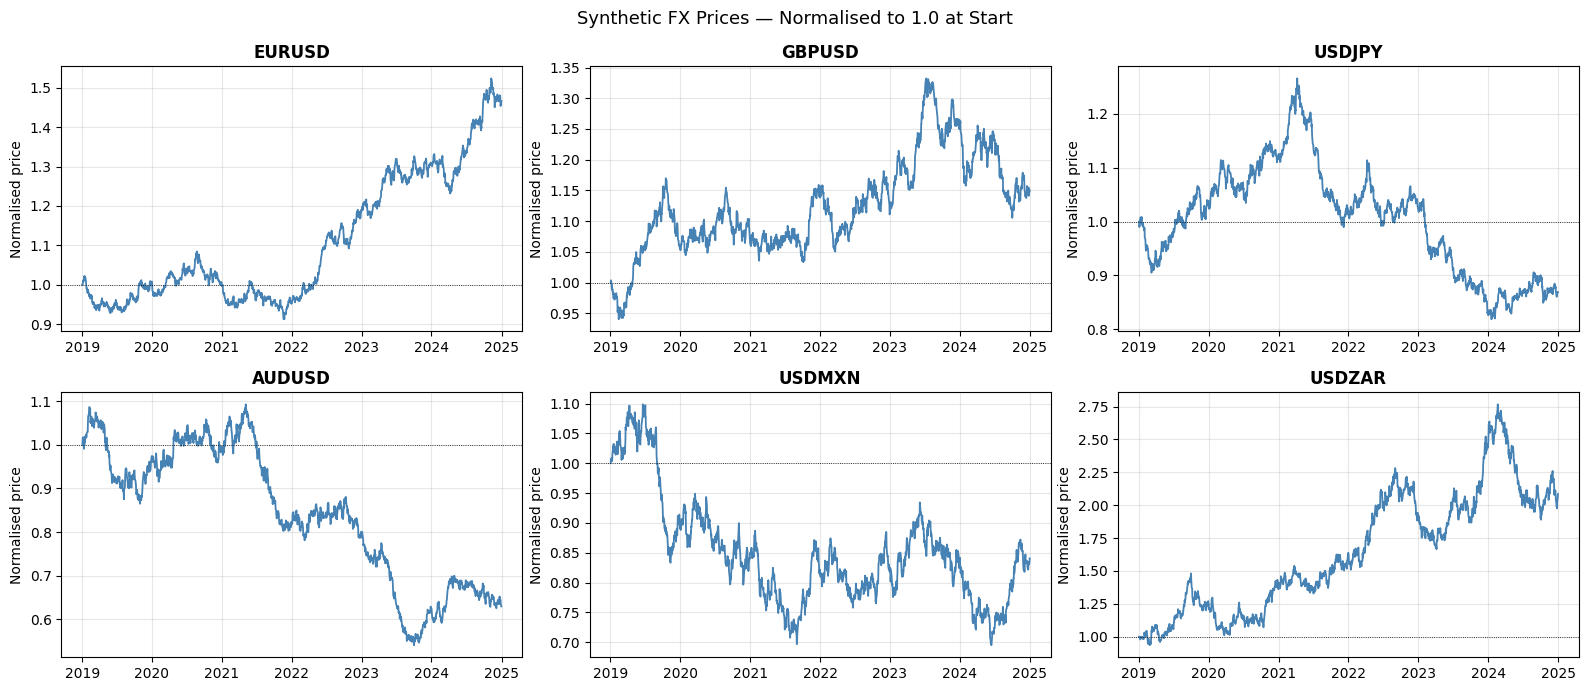

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()
for i, pair in enumerate(PAIRS):
    norm = prices[pair] / prices[pair].iloc[0]
    axes[i].plot(prices.index, norm, lw=1.3, color="steelblue")
    axes[i].axhline(1, color="black", lw=0.6, linestyle=":")
    axes[i].set_title(pair, fontweight="bold")
    axes[i].set_ylabel("Normalised price")
    axes[i].grid(True, alpha=0.3)
fig.suptitle("Synthetic FX Prices — Normalised to 1.0 at Start", fontsize=13)
plt.tight_layout()
plt.show()

---
## 2 — Single Pair Backtest

The simplest possible backtest: one pair, one signal, default costs.

**20-day momentum** on EURUSD — long if price is higher than 20 days ago, short if lower.

In [4]:
sig_eur = momentum(prices[["EURUSD"]], lookback=20)

bt = Backtest(
    data       = prices[["EURUSD"]],
    signals    = sig_eur,
    cost_model = FixedSpreadModel(),
    sizer      = lambda s, p: fixed_size(s, size=1.0),
    freq       = "1D",
    name       = "EURUSD Momentum",
    pnl_mode   = "returns",
)
result_single = bt.run()
result_single.summary()

,EURUSD Momentum
Ann. Return,-1.73%
Ann. Volatility,8.39%
Sharpe Ratio,-0.21
Sortino Ratio,-0.32
Calmar Ratio,-0.08
Max Drawdown,-21.74%
Hit Rate,50.45%
Profit Factor,0.97
Avg Win/Loss,0.95
VaR (95%),-0.90%


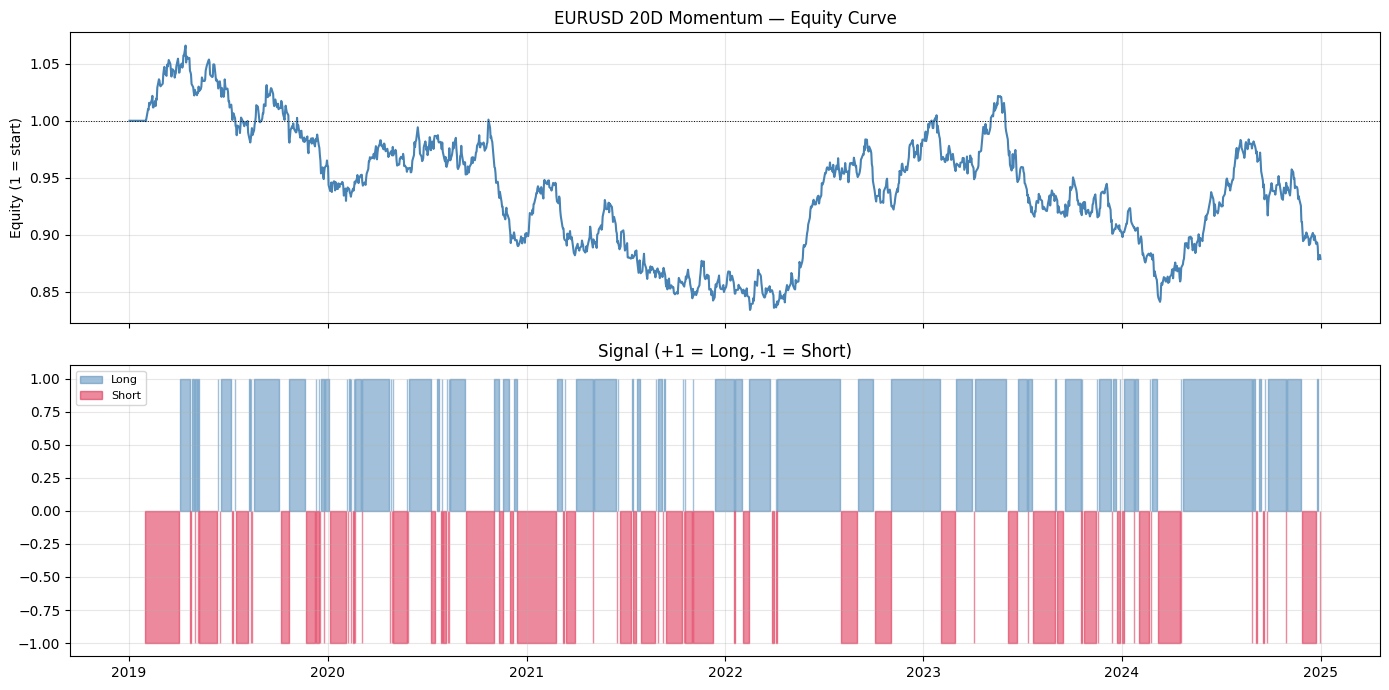

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(result_single.equity_curve, lw=1.5, color="steelblue")
axes[0].axhline(1, color="black", lw=0.7, linestyle=":")
axes[0].set_title("EURUSD 20D Momentum — Equity Curve")
axes[0].set_ylabel("Equity (1 = start)")
axes[0].grid(True, alpha=0.3)

sig_vals = sig_eur["EURUSD"]
axes[1].fill_between(sig_vals.index, sig_vals.values, 0,
                     where=sig_vals > 0, color="steelblue", alpha=0.5, label="Long")
axes[1].fill_between(sig_vals.index, sig_vals.values, 0,
                     where=sig_vals < 0, color="crimson",   alpha=0.5, label="Short")
axes[1].set_title("Signal (+1 = Long, -1 = Short)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3 — Multi-Pair Portfolio

Run the same signal across all 6 pairs simultaneously.
**Vol targeting** scales each pair so the portfolio targets 10% annualised vol.
High-vol EM pairs (USDMXN, USDZAR) automatically receive smaller allocations.

In [6]:
sig_all = momentum(prices, lookback=20)

bt_port = Backtest(
    data       = prices,
    signals    = sig_all,
    cost_model = FixedSpreadModel(slippage_bps=0.5),
    sizer      = lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D"),
    freq       = "1D",
    name       = "6-Pair Momentum (Vol Target 10%)",
    pnl_mode   = "returns",
)
result_port = bt_port.run()
result_port.summary()

,6-Pair Momentum (Vol Target 10%)
Ann. Return,-1.36%
Ann. Volatility,4.29%
Sharpe Ratio,-0.32
Sortino Ratio,-0.52
Calmar Ratio,-0.10
Max Drawdown,-13.89%
Hit Rate,48.32%
Profit Factor,0.95
Avg Win/Loss,1.02
VaR (95%),-0.46%


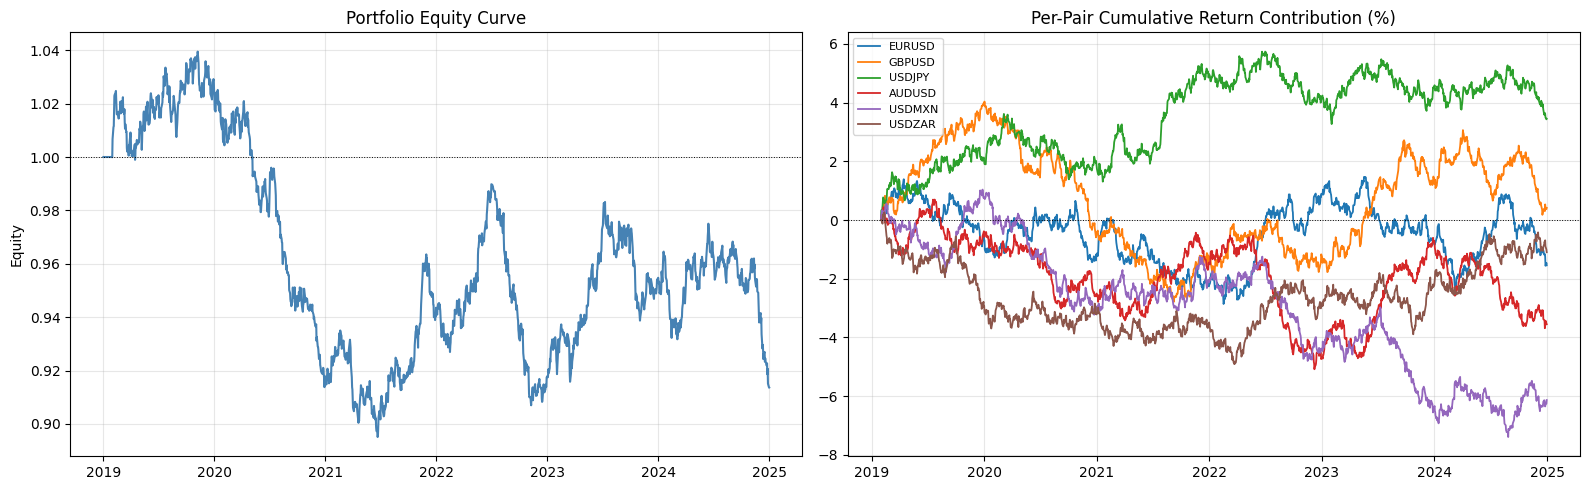

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(result_port.equity_curve, lw=1.5, color="steelblue")
axes[0].axhline(1, color="black", lw=0.7, linestyle=":")
axes[0].set_title("Portfolio Equity Curve")
axes[0].set_ylabel("Equity")
axes[0].grid(True, alpha=0.3)

cum_pair = result_port.pair_returns.cumsum() * 100
for pair in cum_pair.columns:
    axes[1].plot(cum_pair.index, cum_pair[pair], lw=1.3, label=pair)
axes[1].axhline(0, color="black", lw=0.7, linestyle=":")
axes[1].set_title("Per-Pair Cumulative Return Contribution (%)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4 — Comparing All Signal Types

Run every available signal across the same portfolio.
This is how you identify which signal family fits your data best.

In [8]:
sizer      = lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D")
cost_model = FixedSpreadModel(slippage_bps=0.5)

signal_defs = {
    "Momentum":     momentum(prices, lookback=20),
    "MA Crossover": crossover(prices, fast=10, slow=50),
    "MACD":         macd_signal(prices),
    "Breakout":     breakout(prices, lookback=20),
    "Mean Rev":     mean_reversion(prices, lookback=20),
    "RSI":          rsi_signal(prices, period=14),
    "Carry (fwd)":  carry_fwd(fwd_points, prices),
    "Yield Trend":  yield_trend(impl_yield, lookback=252),
}

results_all = {}
for name, sig in signal_defs.items():
    results_all[name] = Backtest(
        data=prices, signals=sig,
        cost_model=cost_model, sizer=sizer,
        freq="1D", name=name, pnl_mode="returns",
    ).run()

compare(*[(r.returns, n) for n, r in results_all.items()], freq="1D")

,Momentum,MA Crossover,MACD,Breakout,Mean Rev,RSI,Carry (fwd),Yield Trend
Ann. Return,-1.36%,-0.52%,-1.99%,-0.02%,0.41%,0.54%,0.48%,-3.25%
Ann. Volatility,4.29%,4.15%,4.27%,2.18%,2.30%,2.02%,4.13%,3.93%
Sharpe Ratio,-0.32,-0.12,-0.47,-0.01,0.18,0.27,0.12,-0.83
Sortino Ratio,-0.52,-0.21,-0.76,-0.01,0.25,0.36,0.20,-1.18
Calmar Ratio,-0.10,-0.04,-0.10,-0.00,0.05,0.15,0.05,-0.16
Max Drawdown,-13.89%,-12.79%,-20.30%,-5.06%,-7.82%,-3.65%,-9.55%,-19.84%
Hit Rate,48.32%,49.64%,47.73%,44.56%,45.81%,46.10%,49.81%,48.44%
Profit Factor,0.95,0.98,0.93,1.00,1.03,1.05,1.02,0.87
Avg Win/Loss,1.02,0.99,1.02,1.24,1.22,1.23,1.03,0.92
VaR (95%),-0.46%,-0.42%,-0.44%,-0.23%,-0.24%,-0.21%,-0.41%,-0.45%


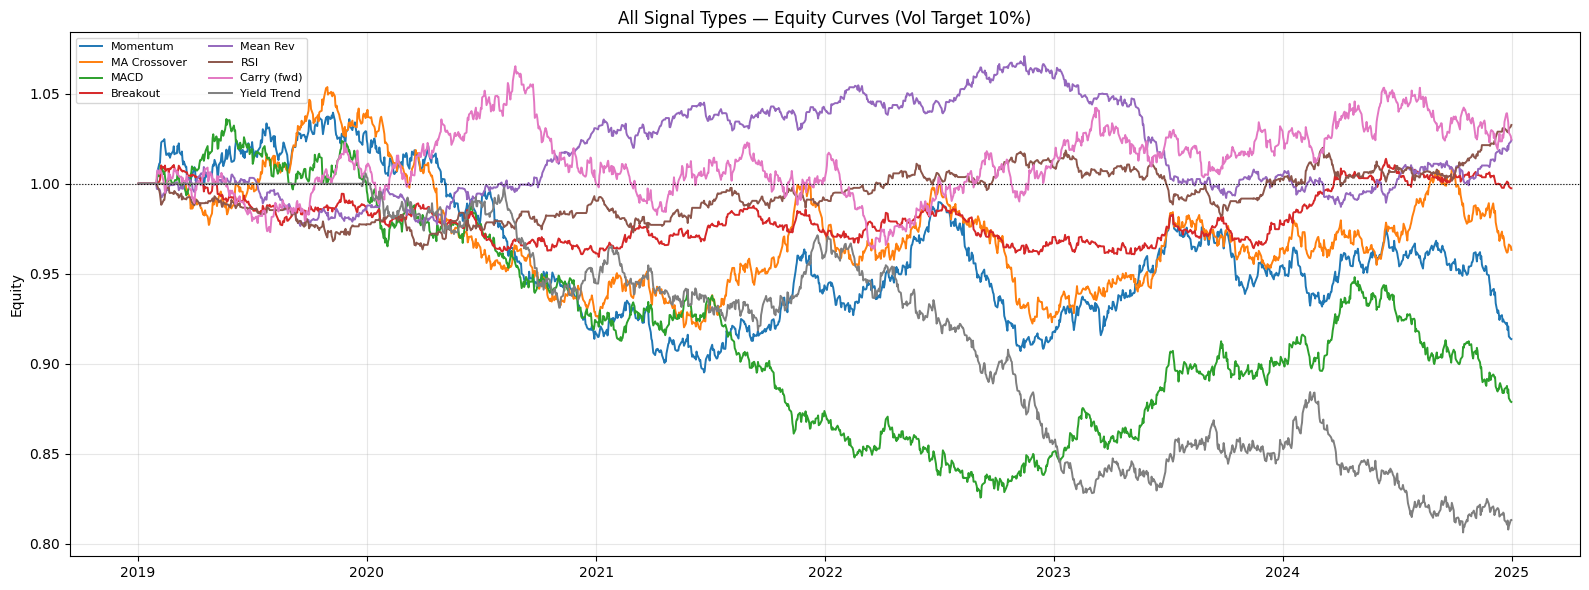

In [9]:
fig, ax = plt.subplots(figsize=(16, 6))
for i, (name, r) in enumerate(results_all.items()):
    ax.plot(r.equity_curve, lw=1.4, label=name, color=plt.cm.tab10.colors[i])
ax.axhline(1, color="black", lw=0.8, linestyle=":")
ax.set_title("All Signal Types — Equity Curves (Vol Target 10%)")
ax.set_ylabel("Equity")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5 — Carry Signals (Macro)

The macro signals use interest rate / carry data rather than price patterns.

- **`carry_yield`** — always-on: long the higher-yielding currency
- **`yield_range`** — selective: only enter when the yield differential is at a historical extreme
- **`yield_trend`** — continuous: follow the *trend* of the rate differential, returns [-1, +1]

In [10]:
carry_signals = {
    "Carry (always-on)": carry_yield(impl_yield, signal_type="sign"),
    "Yield Range":        yield_range(impl_yield, lookback=252),
    "Yield Trend":        yield_trend(impl_yield, lookback=252, ema_span=5),
}

carry_results = {}
for name, sig in carry_signals.items():
    carry_results[name] = Backtest(
        data=prices, signals=sig,
        cost_model=FixedSpreadModel(slippage_bps=0.5),
        sizer=lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D"),
        freq="1D", name=name, pnl_mode="returns",
    ).run()

compare(*[(r.returns, n) for n, r in carry_results.items()], freq="1D")

,Carry (always-on),Yield Range,Yield Trend
Ann. Return,0.48%,-0.81%,-3.25%
Ann. Volatility,4.13%,2.74%,3.93%
Sharpe Ratio,0.12,-0.30,-0.83
Sortino Ratio,0.20,-0.44,-1.18
Calmar Ratio,0.05,-0.12,-0.16
Max Drawdown,-9.55%,-6.80%,-19.84%
Hit Rate,49.81%,47.48%,48.44%
Profit Factor,1.02,0.95,0.87
Avg Win/Loss,1.03,1.05,0.92
VaR (95%),-0.41%,-0.30%,-0.45%


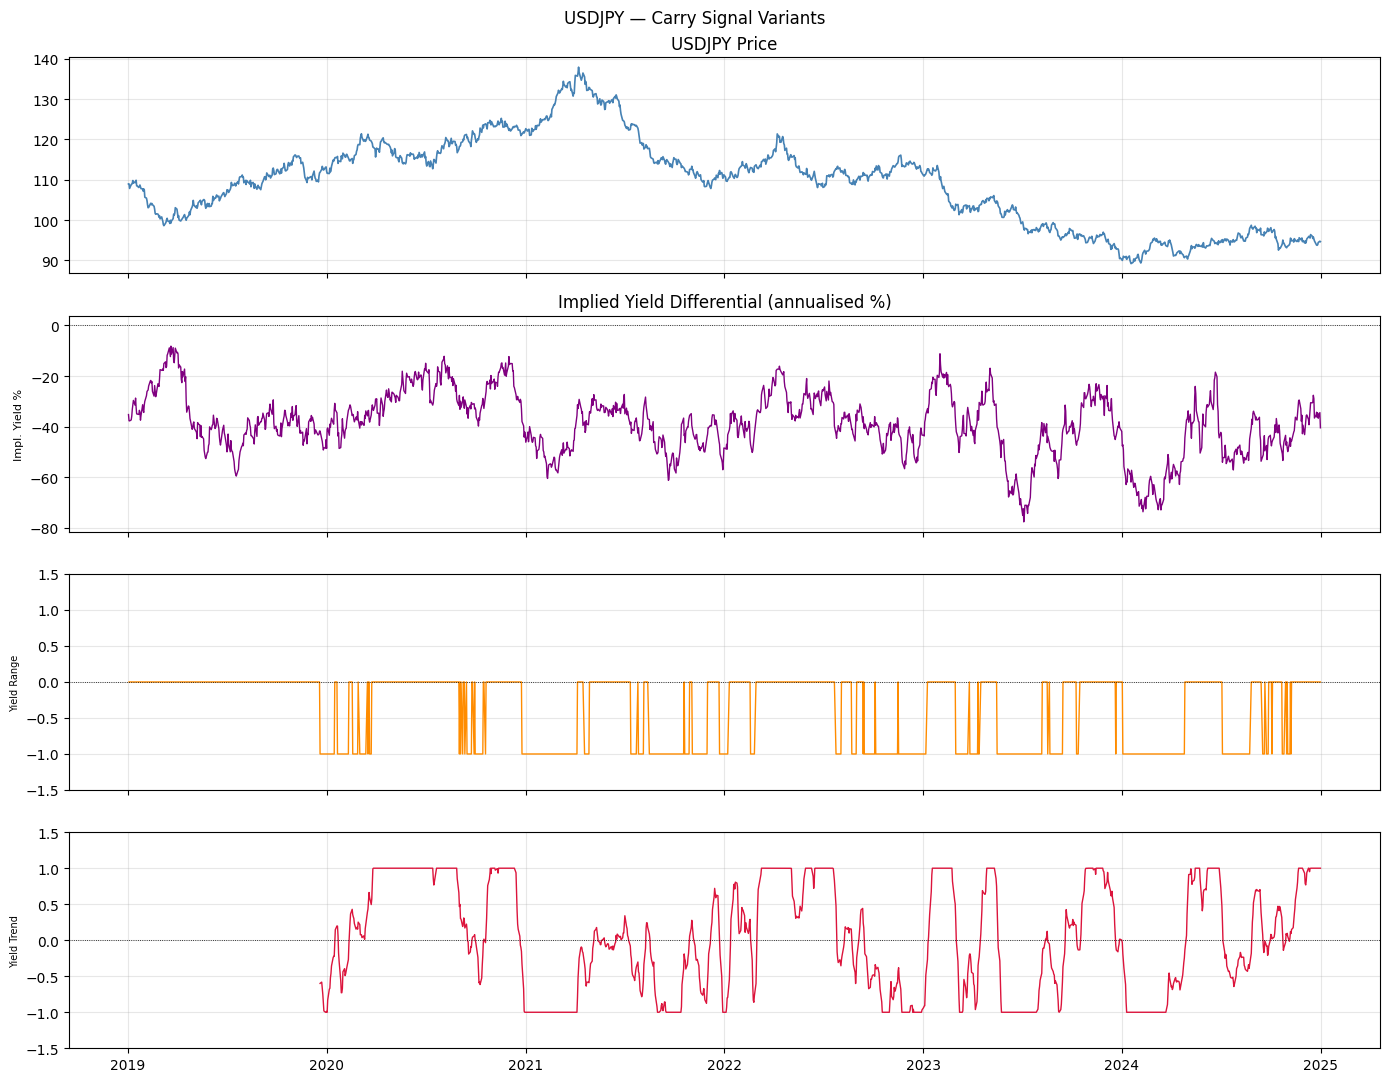

In [11]:
pair = "USDJPY"
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

axes[0].plot(prices.index, prices[pair], lw=1.2, color="steelblue")
axes[0].set_title(f"{pair} Price"); axes[0].grid(True, alpha=0.3)

axes[1].plot(impl_yield.index, impl_yield[pair] * 100, lw=1, color="purple")
axes[1].axhline(0, color="black", lw=0.6, linestyle=":")
axes[1].set_ylabel("Impl. Yield %", fontsize=8)
axes[1].set_title("Implied Yield Differential (annualised %)")
axes[1].grid(True, alpha=0.3)

for ax, col, (name, sig) in zip(axes[2:], ["darkorange", "crimson"],
                                 list(carry_signals.items())[1:]):
    ax.plot(sig[pair], lw=1, color=col)
    ax.axhline(0, color="black", lw=0.6, linestyle=":")
    ax.set_ylabel(name, fontsize=7); ax.set_ylim(-1.5, 1.5); ax.grid(True, alpha=0.3)

fig.suptitle(f"{pair} — Carry Signal Variants", fontsize=12)
plt.tight_layout(); plt.show()

---
## 6 — Notional Mode (Real Dollar PnL)

Switch `pnl_mode` to `"notional"` when you want to think in dollars rather than percentages.
`notional_size` = base USD per unit of signal (here $10M per pair).
The equity curve shows **cumulative USD PnL** starting from zero.

In [12]:
bt_notional = Backtest(
    data          = prices,
    signals       = momentum(prices, lookback=20),
    cost_model    = FixedSpreadModel(slippage_bps=0.5),
    sizer         = lambda s, p: equal_weight(s),
    freq          = "1D",
    name          = "6-Pair Momentum ($10M)",
    pnl_mode      = "notional",
    notional_size = 10_000_000,
)
result_notional = bt_notional.run()
result_notional.summary()

,6-Pair Momentum ($10M)
Total PnL (USD),"$-1,372,929"
Ann. PnL (USD),"$-221,072"
Ann. Volatility (USD),"$583,074"
Sharpe Ratio,-0.38
Sortino Ratio,-0.63
Max Drawdown (USD),"$-2,010,985"
Hit Rate,48.96%
Profit Factor,0.94
Avg Win/Loss,0.98
VaR 95% (USD/day),"$-60,267"


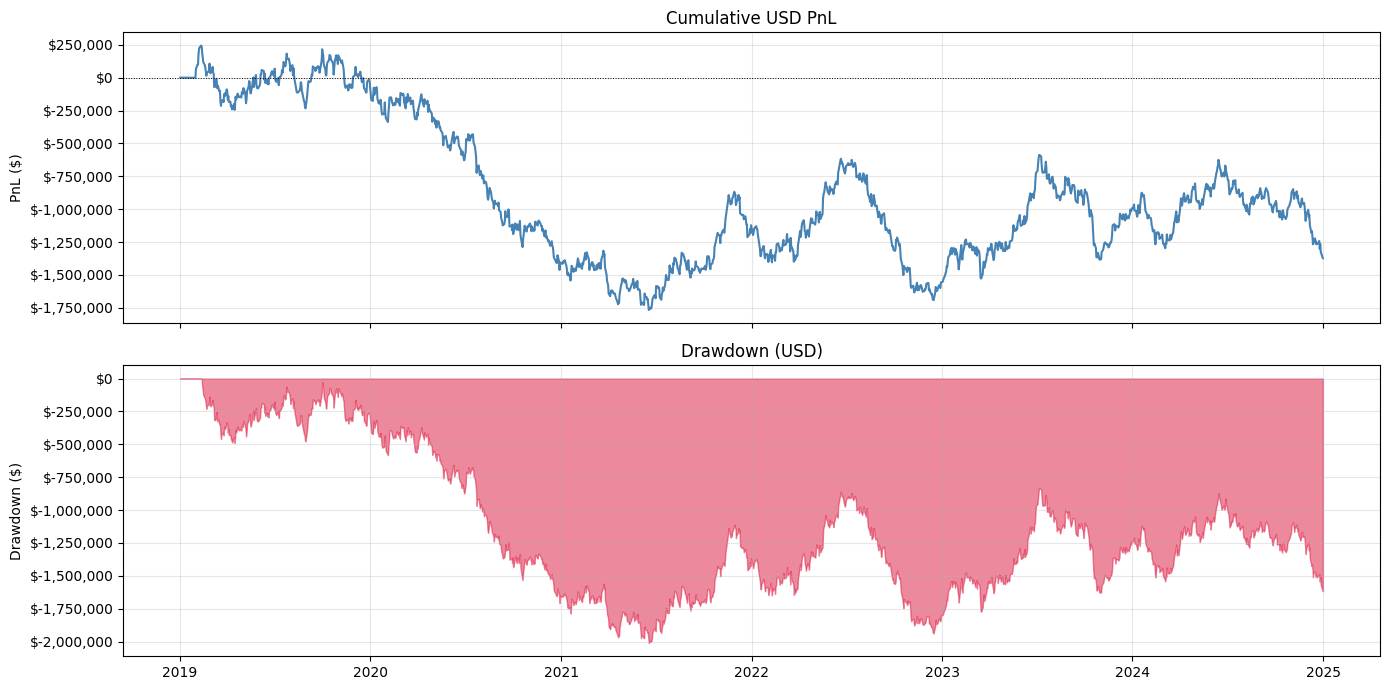

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(result_notional.equity_curve, lw=1.5, color="steelblue")
axes[0].axhline(0, color="black", lw=0.7, linestyle=":")
axes[0].set_title("Cumulative USD PnL")
axes[0].set_ylabel("PnL ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].grid(True, alpha=0.3)

cum = result_notional.returns.cumsum()
dd  = cum - cum.cummax()
axes[1].fill_between(dd.index, dd.values, 0, color="crimson", alpha=0.5)
axes[1].set_title("Drawdown (USD)")
axes[1].set_ylabel("Drawdown ($)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 7 — Position Sizing Methods

The sizer is pluggable — swap it without touching the signal or cost model.

| Sizer | What it does |
|---|---|
| `fixed_size` | Same weight on every trade regardless of vol |
| `equal_weight` | Divides 1.0 equally across all active positions each day |
| `vol_target` | Scales each pair to hit a portfolio vol target |
| `inverse_vol_weight` | Low-vol pairs get bigger weight; high-vol get smaller |
| `kelly` | Sizes by expected return / variance |
| `var_target` | Scales the whole book to hit a fixed daily dollar VaR |

In [14]:
sig_base = momentum(prices, lookback=20)

sizers = {
    "Fixed (0.2)":    lambda s, p: fixed_size(s, size=0.2),
    "Equal Weight":   lambda s, p: equal_weight(s),
    "Vol Target 10%": lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D"),
    "Inv Vol":        lambda s, p: inverse_vol_weight(s, p, lookback=22, rebalance_day=0),
    "Kelly (0.5f)":   lambda s, p: kelly(s, p, lookback=60, fraction=0.5),
}

sizer_results = {}
for name, sz in sizers.items():
    sizer_results[name] = Backtest(
        data=prices, signals=sig_base,
        cost_model=FixedSpreadModel(),
        sizer=sz, freq="1D", name=name, pnl_mode="returns",
    ).run()

compare(*[(r.returns, n) for n, r in sizer_results.items()], freq="1D")

,Fixed (0.2),Equal Weight,Vol Target 10%,Inv Vol,Kelly (0.5f)
Ann. Return,-2.34%,-1.95%,-1.11%,-1.65%,-16.58%
Ann. Volatility,7.00%,5.83%,4.29%,4.89%,63.07%
Sharpe Ratio,-0.34,-0.34,-0.26,-0.34,-0.26
Sortino Ratio,-0.56,-0.56,-0.42,-0.55,-0.41
Calmar Ratio,-0.11,-0.11,-0.08,-0.10,-0.18
Max Drawdown,-21.28%,-18.01%,-13.46%,-16.48%,-93.81%
Hit Rate,49.22%,49.22%,48.45%,48.73%,50.60%
Profit Factor,0.95,0.95,0.96,0.95,0.96
Avg Win/Loss,0.98,0.98,1.02,1.00,0.93
VaR (95%),-0.72%,-0.60%,-0.45%,-0.51%,-6.88%


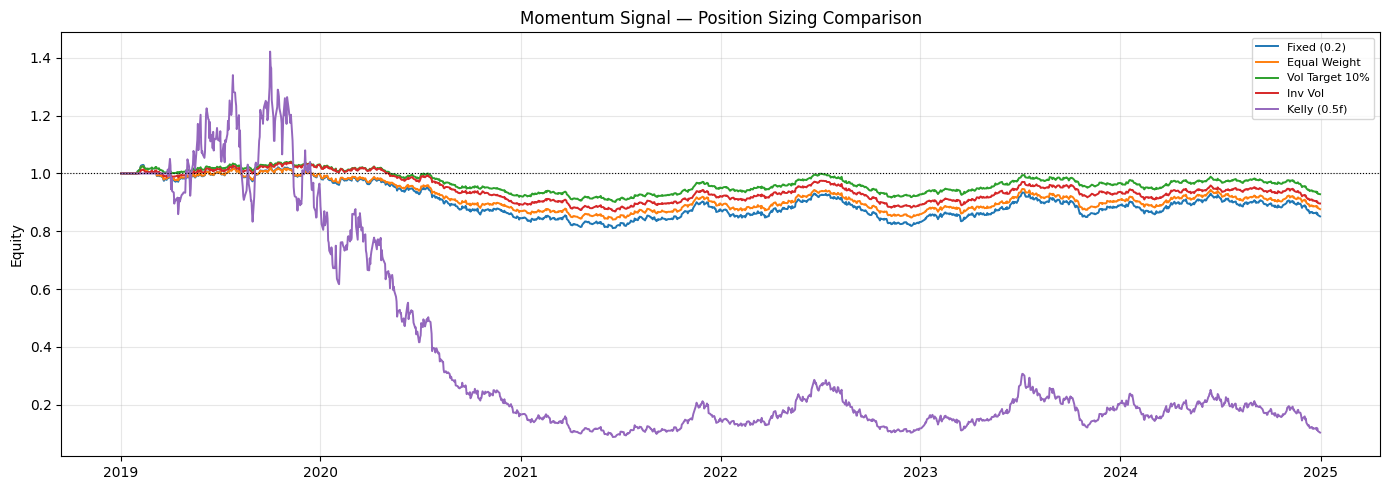

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))
for i, (name, r) in enumerate(sizer_results.items()):
    ax.plot(r.equity_curve, lw=1.4, label=name, color=plt.cm.tab10.colors[i])
ax.axhline(1, color="black", lw=0.8, linestyle=":")
ax.set_title("Momentum Signal — Position Sizing Comparison")
ax.set_ylabel("Equity")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 8 — Transaction Costs

Every backtest includes costs automatically.
- **`FixedSpreadModel`** — built-in pip spread table (25+ pairs). No data needed.
- **`SpreadCostModel`** — uses actual bid/ask. More precise when you have it.

Both accept a `slippage_bps` add-on for market impact.

In [16]:
np.random.seed(7)
SPREAD_BPS = {"EURUSD": 0.3, "GBPUSD": 0.4, "USDJPY": 0.3,
              "AUDUSD": 0.4, "USDMXN": 5.0, "USDZAR": 5.0}
bids = pd.DataFrame({p: prices[p] - prices[p] * sp / 10_000 / 2
                     for p, sp in SPREAD_BPS.items()}, index=dates)
asks = pd.DataFrame({p: prices[p] + prices[p] * sp / 10_000 / 2
                     for p, sp in SPREAD_BPS.items()}, index=dates)

sig_c = momentum(prices, lookback=20)
sz_c  = lambda s, p: equal_weight(s)

r_nocost = Backtest(prices, sig_c,
                    FixedSpreadModel(spreads_pips={p: 0 for p in PAIRS}),
                    sz_c, name="No Costs", pnl_mode="returns").run()
r_fixed  = Backtest(prices, sig_c, FixedSpreadModel(slippage_bps=0.5),
                    sz_c, name="Fixed Spread", pnl_mode="returns").run()
r_ba     = Backtest(prices, sig_c, SpreadCostModel(slippage_bps=0.5),
                    sz_c, name="Bid/Ask", pnl_mode="returns",
                    bids=bids, asks=asks).run()

compare((r_nocost.returns, "No Costs"),
        (r_fixed.returns,  "Fixed Spread"),
        (r_ba.returns,     "Bid/Ask"), freq="1D")

,No Costs,Fixed Spread,Bid/Ask
Ann. Return,-1.79%,-2.21%,-2.52%
Ann. Volatility,5.83%,5.83%,5.83%
Sharpe Ratio,-0.31,-0.38,-0.43
Sortino Ratio,-0.51,-0.63,-0.72
Calmar Ratio,-0.10,-0.12,-0.13
Max Drawdown,-17.68%,-18.56%,-19.28%
Hit Rate,49.32%,48.96%,48.90%
Profit Factor,0.95,0.94,0.93
Avg Win/Loss,0.98,0.98,0.98
VaR (95%),-0.60%,-0.60%,-0.60%


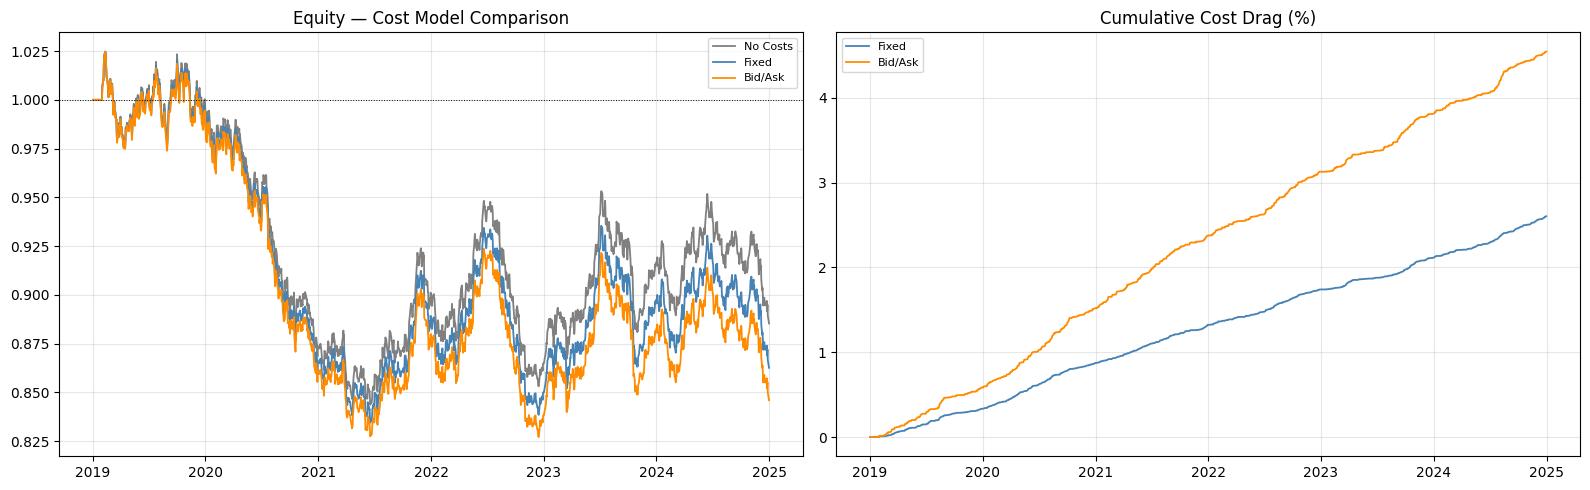

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for name, r, col in [("No Costs", r_nocost, "gray"),
                     ("Fixed",    r_fixed,  "steelblue"),
                     ("Bid/Ask",  r_ba,     "darkorange")]:
    axes[0].plot(r.equity_curve, lw=1.3, label=name, color=col)
axes[0].axhline(1, color="black", lw=0.7, linestyle=":")
axes[0].set_title("Equity — Cost Model Comparison")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].plot(r_fixed.costs.cumsum() * 100, lw=1.3, label="Fixed",   color="steelblue")
axes[1].plot(r_ba.costs.cumsum()    * 100, lw=1.3, label="Bid/Ask", color="darkorange")
axes[1].set_title("Cumulative Cost Drag (%)")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## 9 — Portfolio Risk Tools

After running a backtest you can decompose risk by pair and monitor VaR.

In [18]:
# Risk attribution: which pair drives the most portfolio variance?
ra = risk_attribution(result_port.pair_returns, freq="1D")
print("Risk Attribution — 6-Pair Momentum (Vol Target):")
ra

Risk Attribution — 6-Pair Momentum (Vol Target):


,ann_vol,pct_vol_contrib,sharpe,total_return
EURUSD,0.0178,0.1755,-0.1417,-0.0154
GBPUSD,0.0176,0.1698,0.0384,0.0042
USDJPY,0.0175,0.1637,0.3220,0.0345
AUDUSD,0.0175,0.1759,-0.3312,-0.0355
USDMXN,0.0176,0.1755,-0.5672,-0.0613
USDZAR,0.0175,0.1533,-0.1022,-0.0110


In [19]:
# Net currency exposure across the book
net_exp = net_ccy_exposure(result_notional.positions)
print("Net currency exposure (last row):")
print(net_exp.iloc[-1].round(0).sort_values())

Net currency exposure (last row):
EUR   -1666667.0
GBP   -1666667.0
JPY   -1666667.0
MXN   -1666667.0
AUD    1666667.0
ZAR    1666667.0
USD    3333333.0
Name: 2024-12-31 00:00:00, dtype: float64


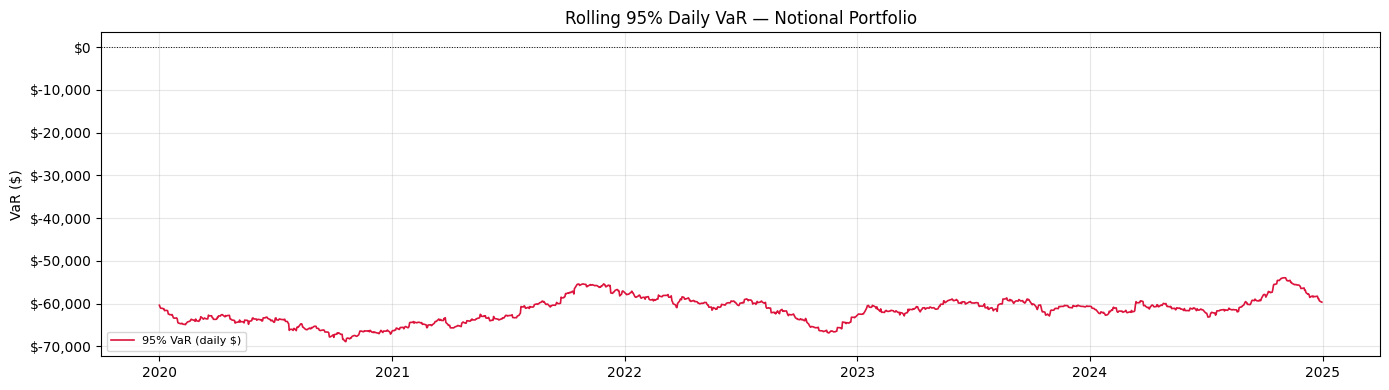

In [20]:
var_series = rolling_var(result_notional.returns.cumsum(), window=260, confidence=0.05)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(var_series.dropna(), lw=1.2, color="crimson", label="95% VaR (daily $)")
ax.axhline(0, color="black", lw=0.7, linestyle=":")
ax.set_title("Rolling 95% Daily VaR — Notional Portfolio")
ax.set_ylabel("VaR ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 10 — Walk-Forward (Out-of-Sample Validation)

In-sample results always look better than reality — the model has seen the data it is tested on.

Walk-forward splits history into rolling **train / test** windows:
- **Train** (1 year) — signal is calibrated here
- **Test** (1 quarter) — signal applied to unseen data

All test windows are stitched together to give a genuine out-of-sample track record.

In [21]:
def wf_signal(train_prices, test_prices):
    combined = pd.concat([train_prices, test_prices])
    sig = momentum(combined, lookback=20)
    return sig.loc[test_prices.index]

result_wf = Backtest(
    data=prices, signals=sig_all,
    cost_model=FixedSpreadModel(slippage_bps=0.5),
    sizer=lambda s, p: vol_target(s, p, target_vol=0.10, lookback=20, freq="1D"),
    freq="1D", name="Walk-Forward", pnl_mode="returns",
).walk_forward(train_periods=252, test_periods=63, signal_fn=wf_signal)

compare((result_port.returns, "In-Sample"),
        (result_wf.returns,   "Walk-Forward OOS"), freq="1D")

,In-Sample,Walk-Forward OOS
Ann. Return,-1.36%,-0.60%
Ann. Volatility,4.29%,3.56%
Sharpe Ratio,-0.32,-0.17
Sortino Ratio,-0.52,-0.23
Calmar Ratio,-0.10,-0.06
Max Drawdown,-13.89%,-9.41%
Hit Rate,48.32%,47.50%
Profit Factor,0.95,0.97
Avg Win/Loss,1.02,1.07
VaR (95%),-0.46%,-0.38%


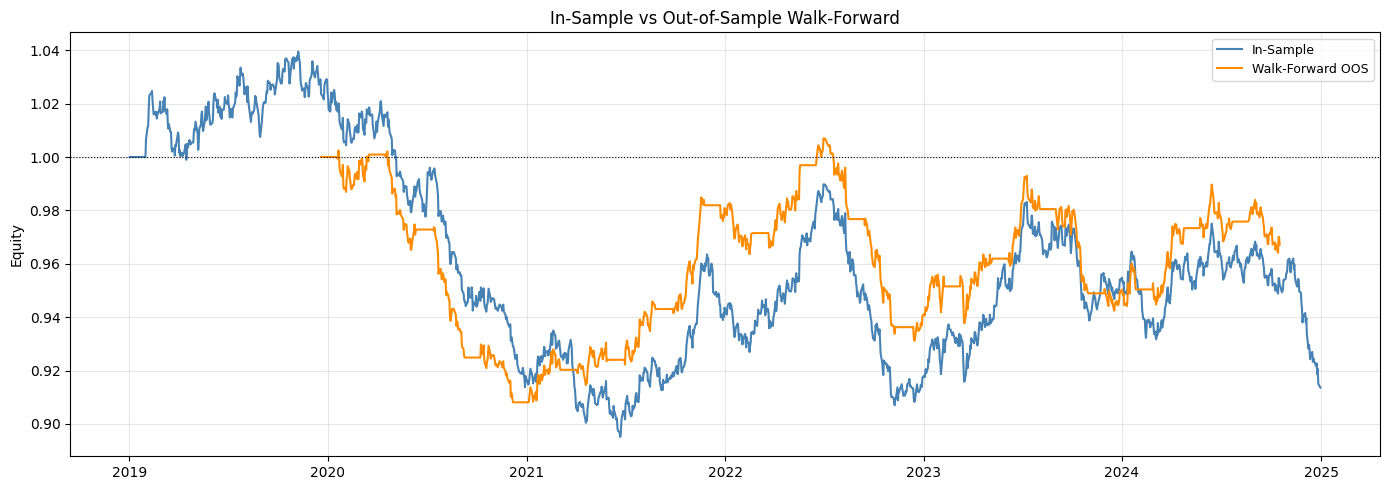

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(result_port.equity_curve, lw=1.5, color="steelblue",  label="In-Sample")
ax.plot(result_wf.equity_curve,   lw=1.5, color="darkorange", label="Walk-Forward OOS")
ax.axhline(1, color="black", lw=0.8, linestyle=":")
ax.set_title("In-Sample vs Out-of-Sample Walk-Forward")
ax.set_ylabel("Equity"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 11 — VaR-Targeted Sizing

Scale the book so the daily VaR stays at a fixed dollar limit at 95% confidence.
Used in the original RCQ desk strategies.

**Three steps:**
1. Run an unscaled base backtest to get a PnL history
2. Feed that history into `var_target` to compute daily scaling multipliers
3. Run the final backtest with the scaled signals

In [23]:
# Step 1 — unscaled run
r_base = Backtest(
    data=prices, signals=momentum(prices, lookback=20),
    cost_model=FixedSpreadModel(),
    sizer=lambda s, p: fixed_size(s, size=1.0),
    freq="1D", pnl_mode="notional", notional_size=1_000_000,
).run()

# Step 2 — compute scaling multipliers
TARGET_VAR  = 20_000
sig_var_adj = var_target(
    signals        = momentum(prices, lookback=20),
    pnl_series     = r_base.returns.cumsum(),
    var_window     = 260,
    var_target_usd = TARGET_VAR,
    confidence     = 0.05,
)

# Step 3 — run scaled backtest
r_var = Backtest(
    data=prices, signals=sig_var_adj,
    cost_model=FixedSpreadModel(),
    sizer=lambda s, p: s,
    freq="1D", name=f"VaR Target ${TARGET_VAR:,}",
    pnl_mode="notional", notional_size=1_000_000,
).run()

r_var.summary()

,"VaR Target $20,000"
Total PnL (USD),"$-328,657"
Ann. PnL (USD),"$-52,921"
Ann. Volatility (USD),"$174,284"
Sharpe Ratio,-0.30
Sortino Ratio,-0.46
Max Drawdown (USD),"$-512,813"
Hit Rate,49.00%
Profit Factor,0.95
Avg Win/Loss,0.99
VaR 95% (USD/day),"$-18,784"


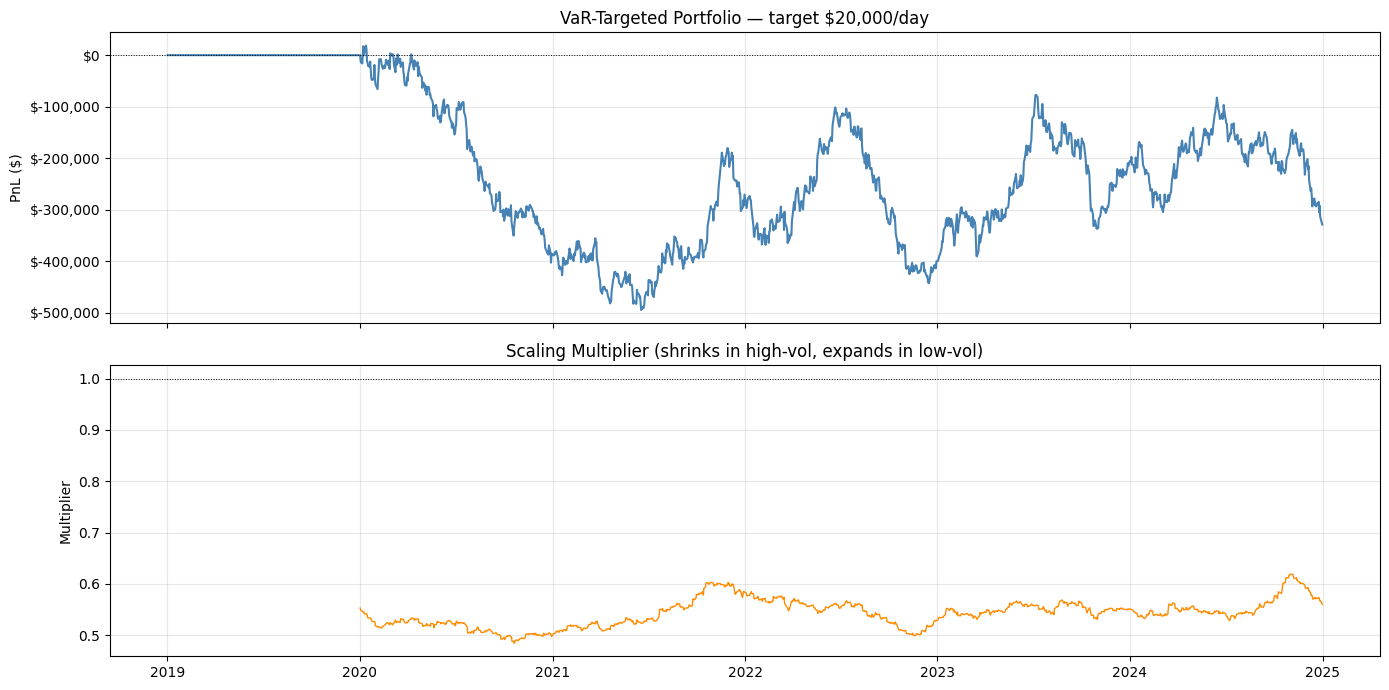

In [24]:
adj_mult = sig_var_adj.abs().mean(axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(r_var.equity_curve, lw=1.5, color="steelblue")
axes[0].axhline(0, color="black", lw=0.7, linestyle=":")
axes[0].set_title(f"VaR-Targeted Portfolio — target ${TARGET_VAR:,}/day")
axes[0].set_ylabel("PnL ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].grid(True, alpha=0.3)

axes[1].plot(adj_mult.dropna(), lw=1, color="darkorange")
axes[1].axhline(1, color="black", lw=0.7, linestyle=":")
axes[1].set_title("Scaling Multiplier (shrinks in high-vol, expands in low-vol)")
axes[1].set_ylabel("Multiplier"); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 12 — Full Tear Sheet

`plot_tearsheet()` generates a single 6-panel summary page covering equity, drawdown,
rolling Sharpe, monthly returns heatmap, per-pair contribution, and a stats table.
Labels and axis formats adapt automatically to returns vs notional mode.

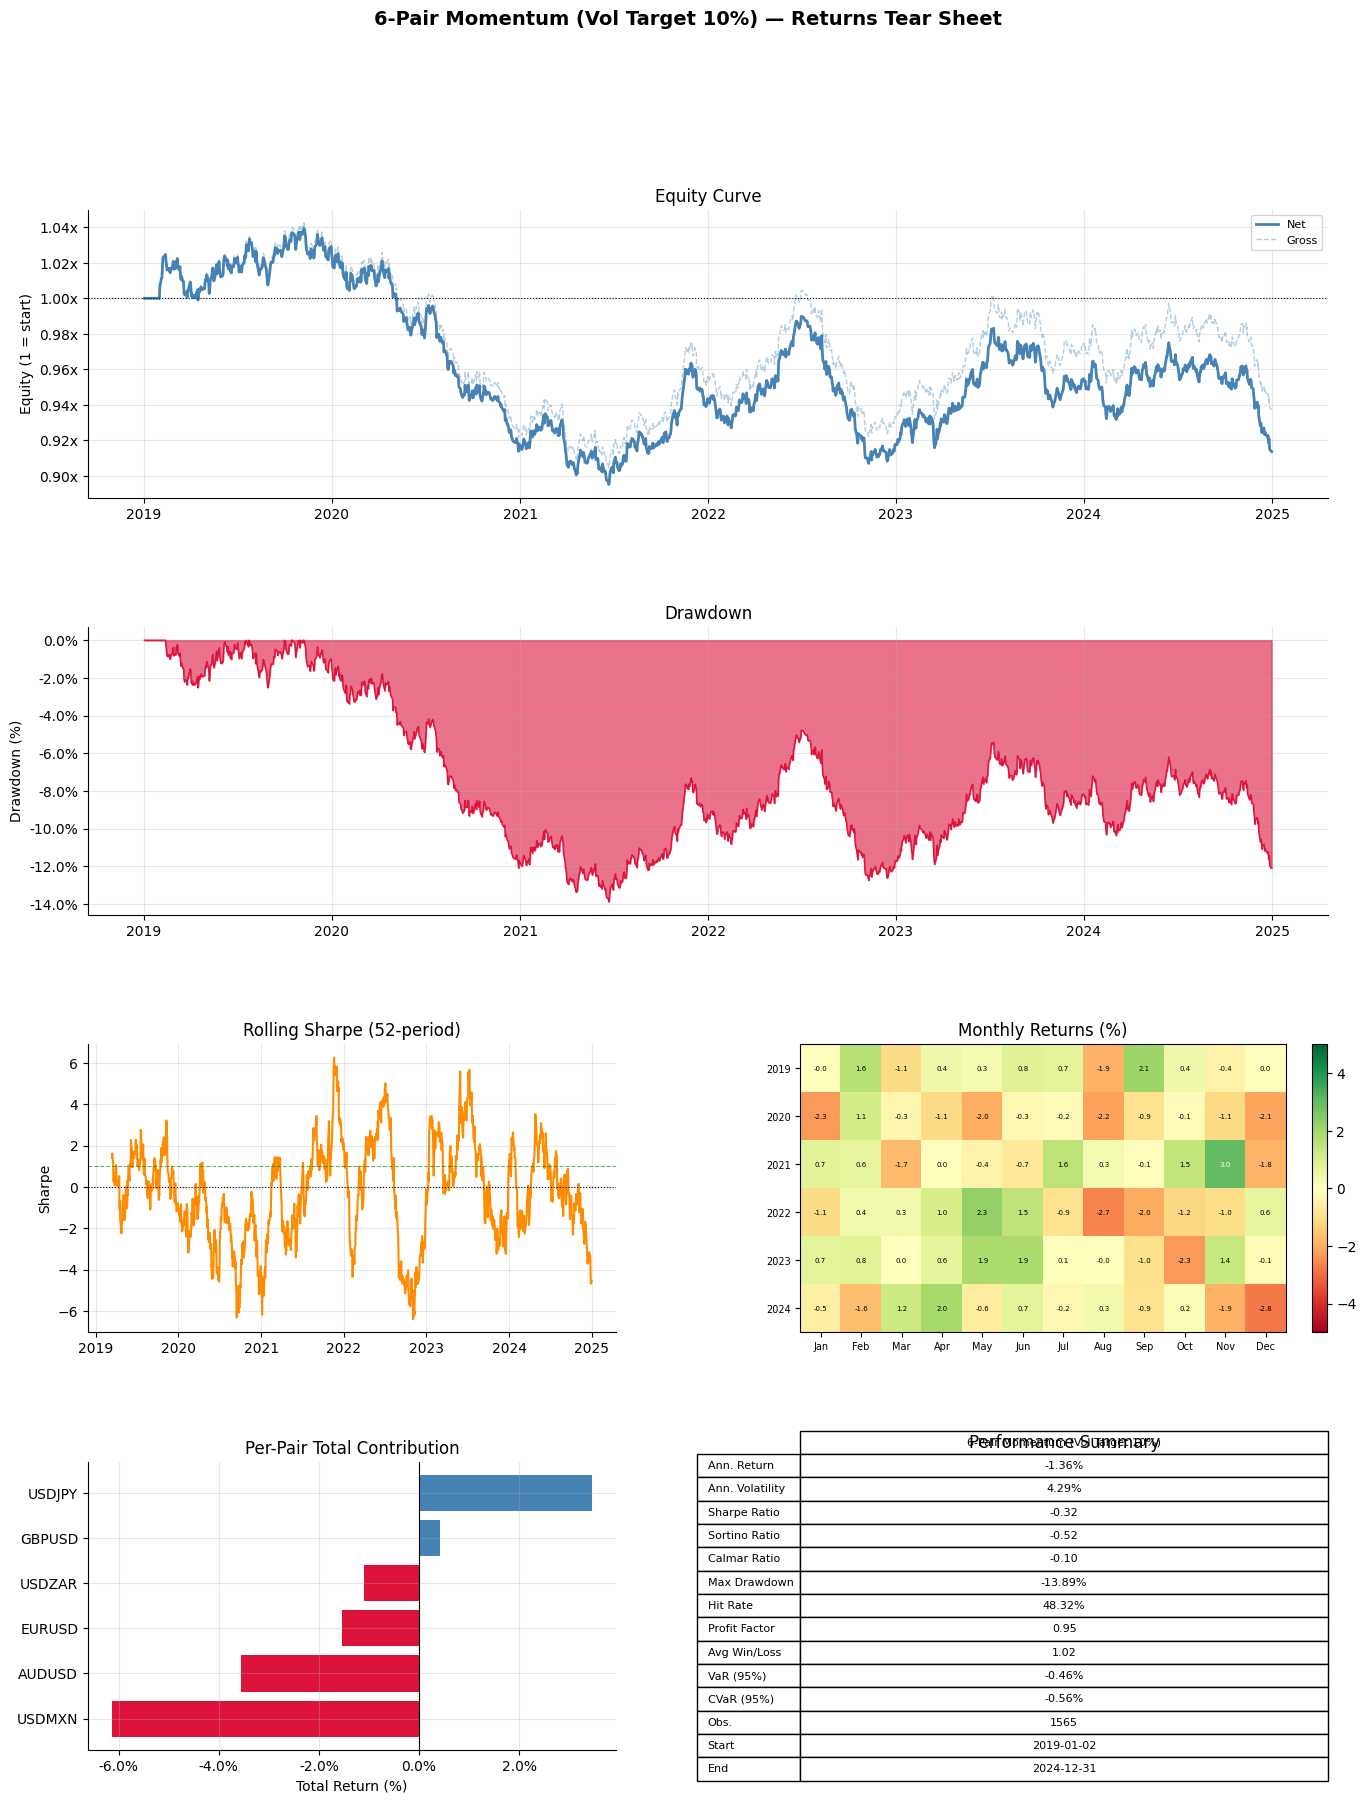

In [25]:
# Returns mode
fig = plot_tearsheet(result_port, figsize=(16, 20))

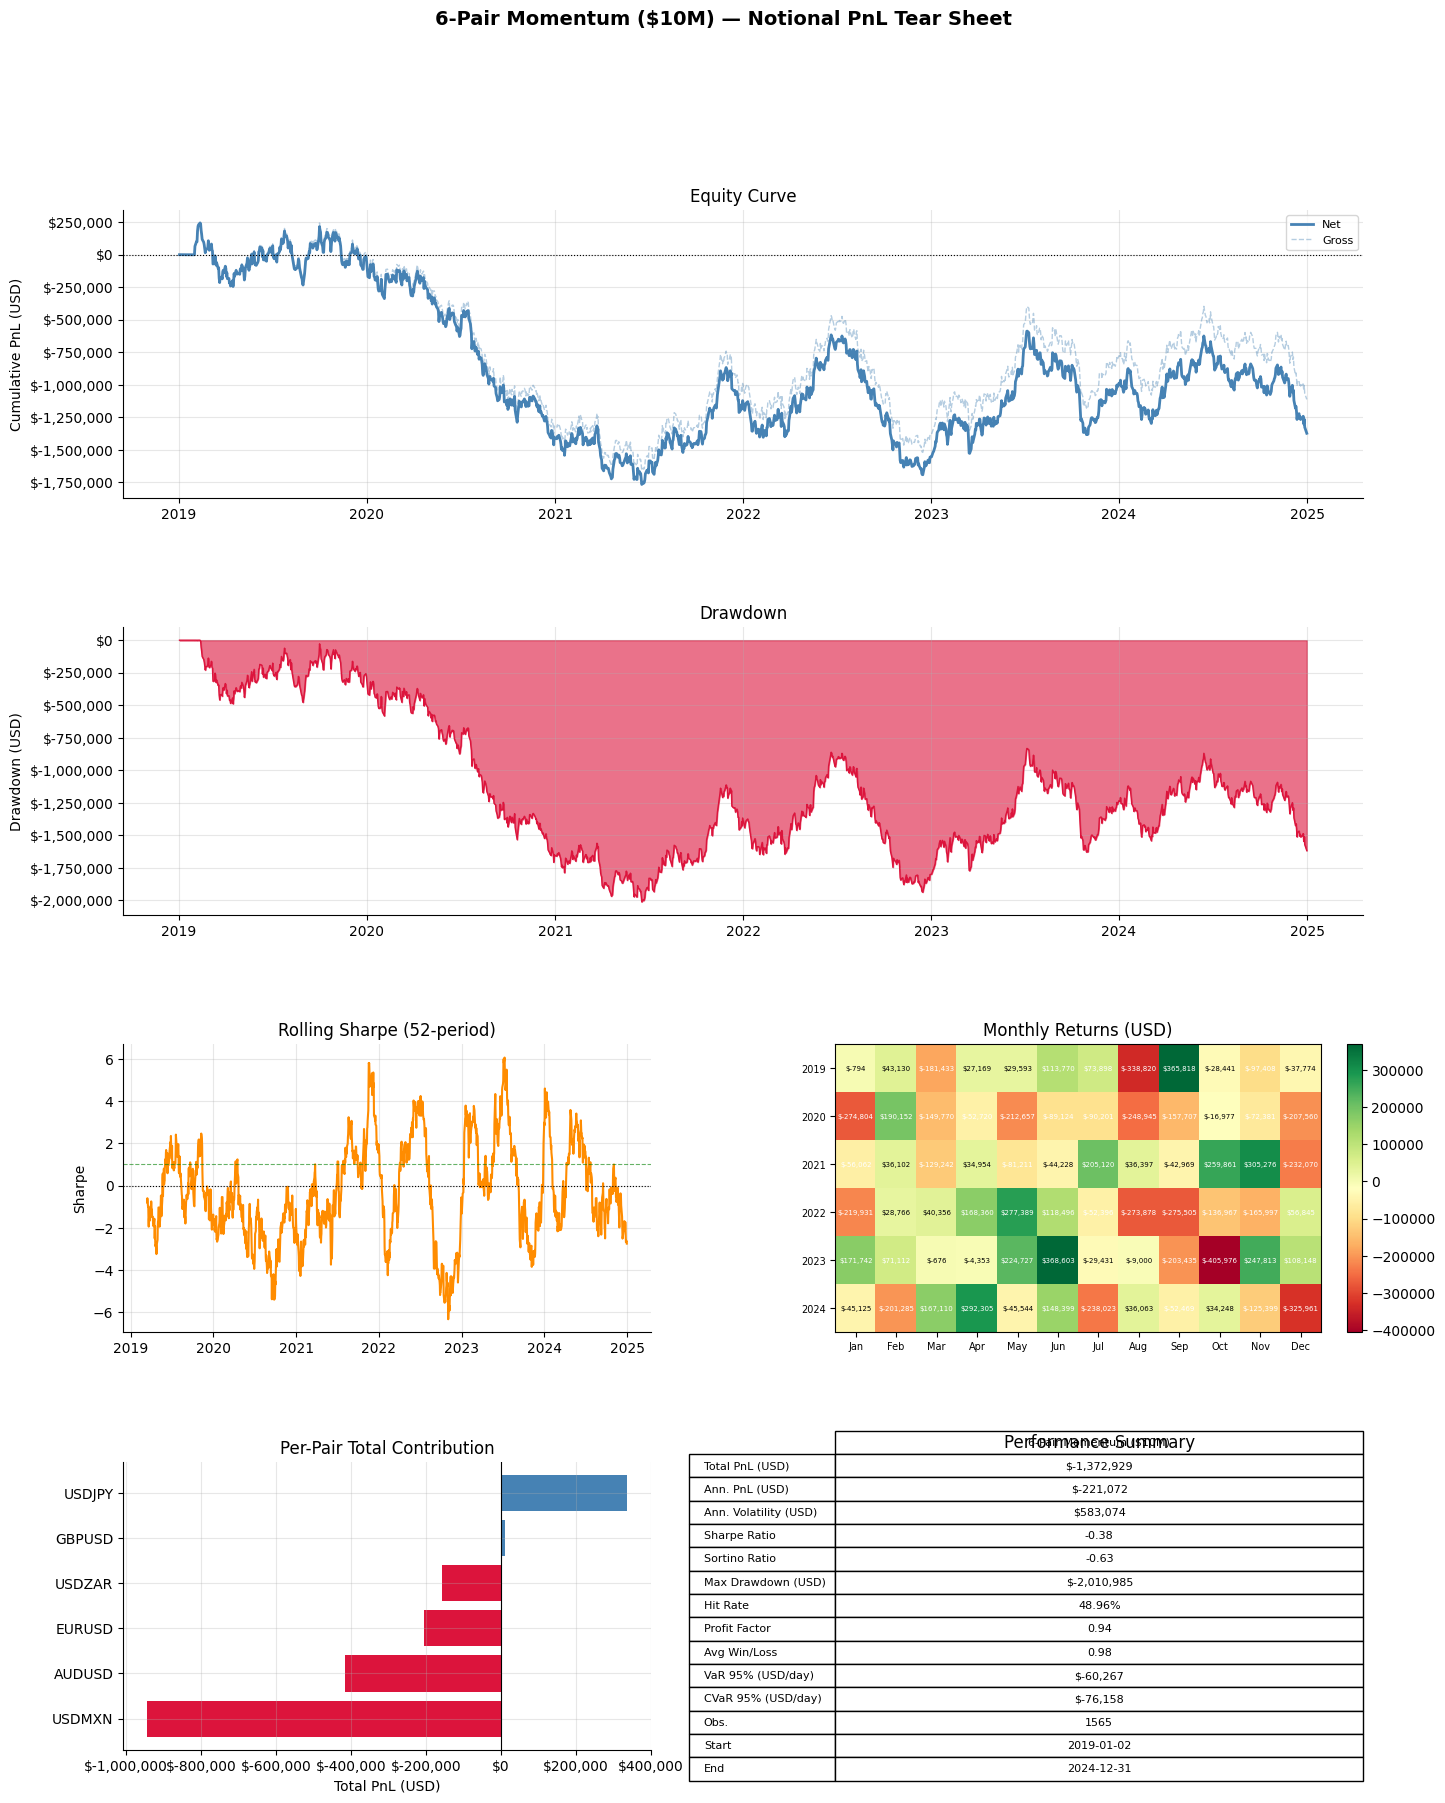

In [26]:
# Notional mode — axes show USD throughout
fig = plot_tearsheet(result_notional, figsize=(16, 20))